In [1]:
# ml_training/notebooks/01_eda.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
engine = create_engine(os.getenv("POSTGRES_URL"))

In [2]:
# ── 1. Tổng quan dataset ────────────────────────────────────────────────────
df = pd.read_sql("""
    SELECT * FROM aqi_records
    ORDER BY village, timestamp
""", engine, parse_dates=["timestamp"])

print(f"Tổng records : {len(df):,}")
print(f"Số làng      : {df['village'].nunique()}")
print(f"Từ ngày      : {df['timestamp'].min()}")
print(f"Đến ngày     : {df['timestamp'].max()}")
print(f"\nCác cột:\n{df.dtypes}")
print(f"\nMissing (%):\n{(df.isnull().mean()*100).round(2)}")

Tổng records : 547,417
Số làng      : 17
Từ ngày      : 2022-08-04 07:00:00+00:00
Đến ngày     : 2026-04-06 23:00:00+00:00

Các cột:
timestamp        datetime64[us, UTC]
village                          str
lat                          float64
lon                          float64
pm25                         float64
pm10                         float64
so2                          float64
no2                          float64
co                           float64
o3                           float64
aqi_eu                       float64
us_aqi                       float64
temperature                  float64
humidity                       int64
wind_speed                   float64
wind_dir                       int64
precipitation                float64
pressure                     float64
cloud_cover                    int64
aod                          float64
dust                         float64
is_forecast                     bool
source                           str
hour            

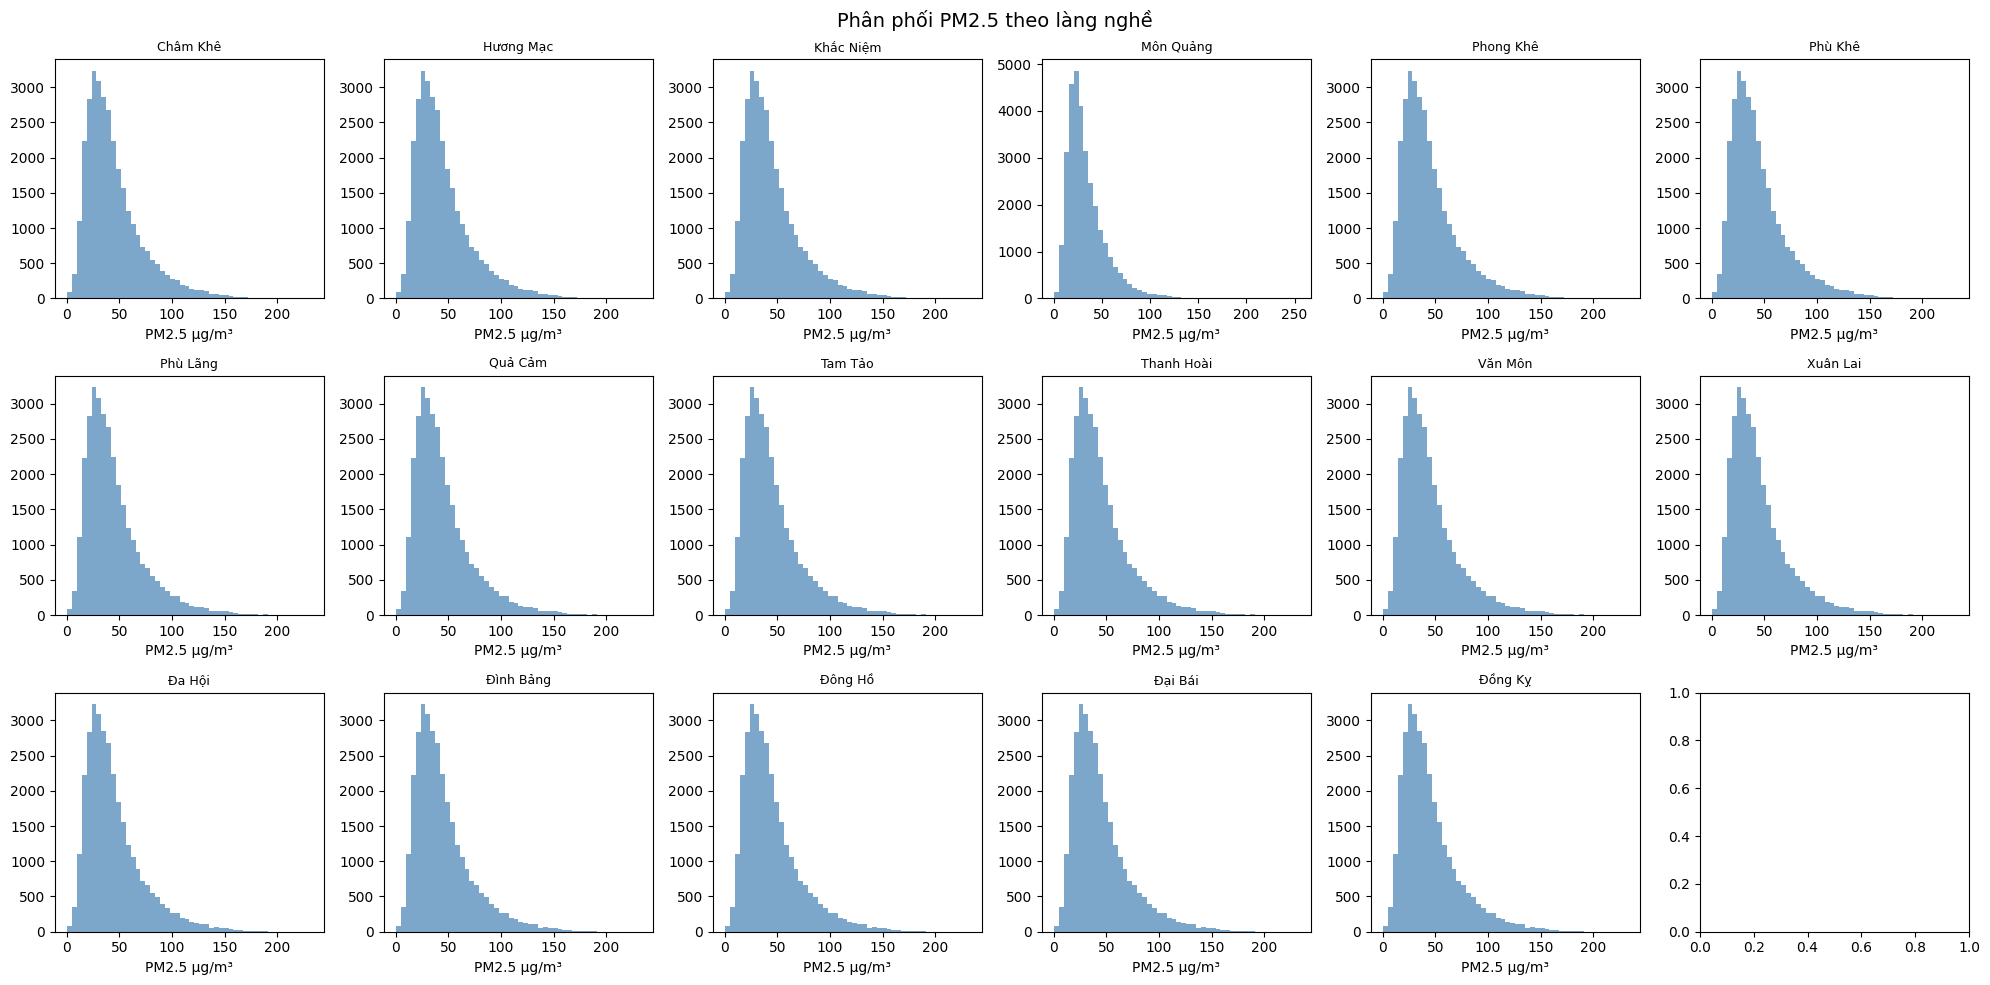

In [4]:
# ── 2. Phân phối PM2.5 theo làng ────────────────────────────────────────────
from pathlib import Path

# Tạo thư mục outputs nếu chưa tồn tại
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()
for i, (village, grp) in enumerate(df.groupby("village")):
    axes[i].hist(grp["pm25"].dropna(), bins=50, color="steelblue", alpha=0.7)
    axes[i].set_title(village, fontsize=9)
    axes[i].set_xlabel("PM2.5 µg/m³")
plt.suptitle("Phân phối PM2.5 theo làng nghề", fontsize=14)
plt.tight_layout()
plt.savefig(output_dir / "eda_pm25_dist.png", dpi=120)
plt.show()


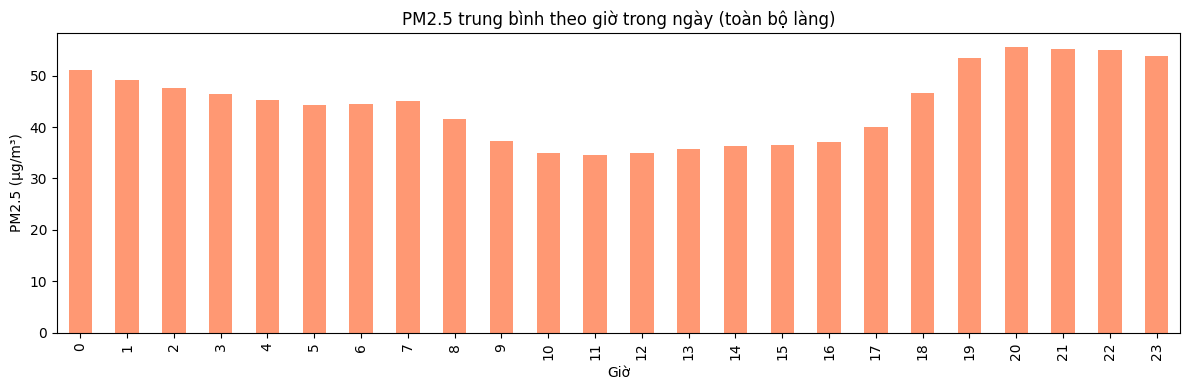

In [5]:
# ── 3. PM2.5 trung bình theo giờ trong ngày ─────────────────────────────────
df["hour"] = df["timestamp"].dt.hour
hourly_avg = df.groupby("hour")["pm25"].mean()

plt.figure(figsize=(12, 4))
hourly_avg.plot(kind="bar", color="coral", alpha=0.8)
plt.title("PM2.5 trung bình theo giờ trong ngày (toàn bộ làng)")
plt.xlabel("Giờ")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig(output_dir / "eda_hourly_pattern.png", dpi=120)

plt.show()

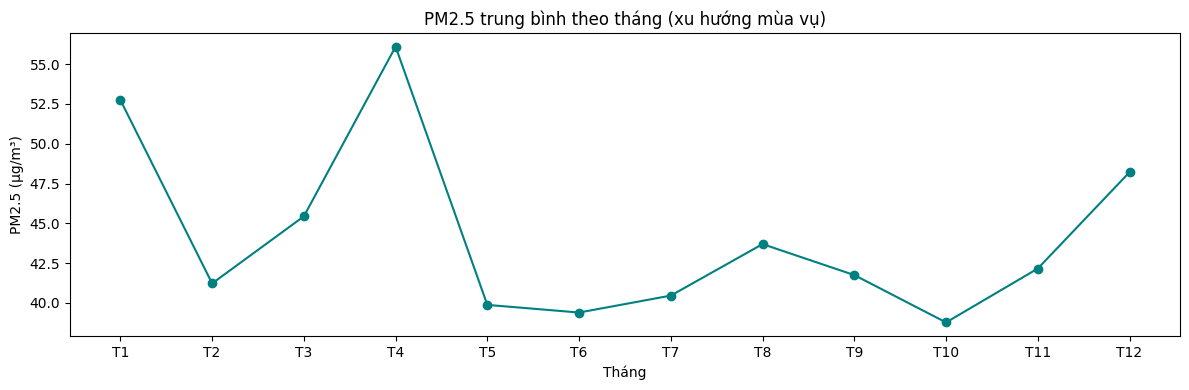

In [7]:
# ── 4. PM2.5 trung bình theo tháng ──────────────────────────────────────────
df["month"] = df["timestamp"].dt.month
monthly_avg = df.groupby("month")["pm25"].mean()

plt.figure(figsize=(12, 4))
monthly_avg.plot(marker="o", color="teal")
plt.title("PM2.5 trung bình theo tháng (xu hướng mùa vụ)")
plt.xlabel("Tháng")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(1, 13), ["T1","T2","T3","T4","T5","T6",
                            "T7","T8","T9","T10","T11","T12"])
plt.tight_layout()
plt.savefig(output_dir / "eda_monthly.png", dpi=120)
plt.show()

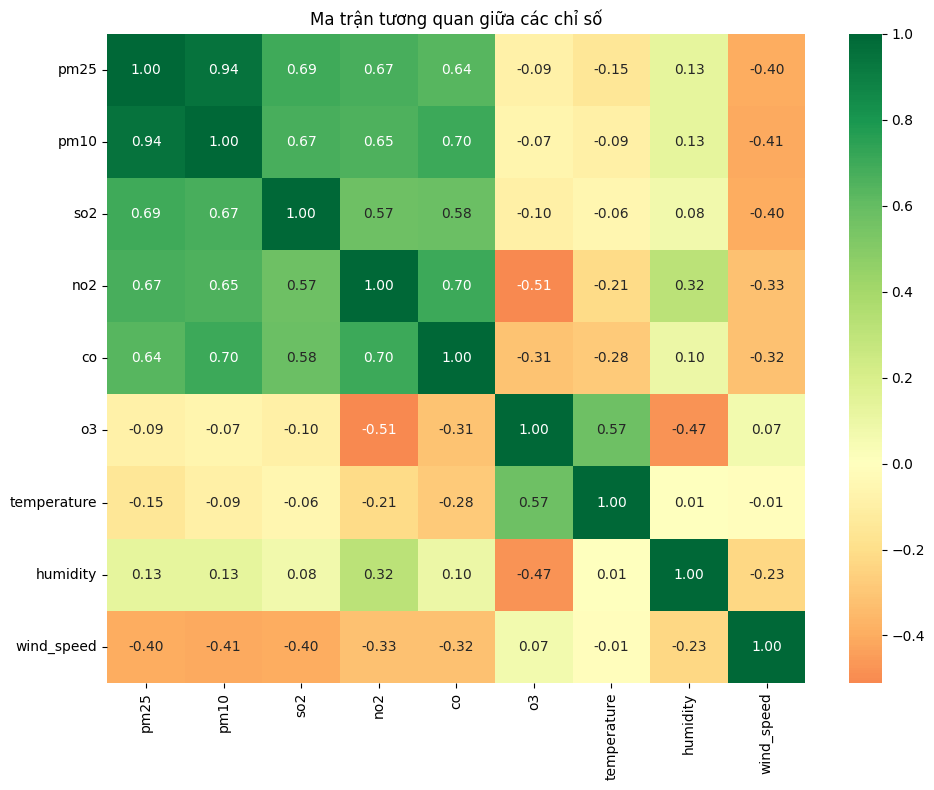

In [8]:
# ── 5. Ma trận tương quan ────────────────────────────────────────────────────
corr_cols = ["pm25", "pm10", "so2", "no2", "co", "o3",
             "temperature", "humidity", "wind_speed"]
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", center=0)
plt.title("Ma trận tương quan giữa các chỉ số")
plt.tight_layout()

plt.savefig(output_dir / "eda_correlation.png", dpi=120)
plt.show()

In [9]:
# ── 6. Kiểm tra tính liên tục thời gian ─────────────────────────────────────
print("\n=== Khoảng trống dữ liệu lớn nhất mỗi làng ===")
for village, grp in df.groupby("village"):
    grp = grp.sort_values("timestamp")
    gaps = grp["timestamp"].diff().dt.total_seconds() / 3600
    max_gap = gaps.max()
    pct_missing = (gaps > 2).sum() / len(gaps) * 100
    print(f"  {village:<20} max gap={max_gap:6.0f}h  "
          f"missing>2h={pct_missing:.1f}%")


=== Khoảng trống dữ liệu lớn nhất mỗi làng ===
  Châm Khê             max gap=     1h  missing>2h=0.0%
  Hương Mạc            max gap=     1h  missing>2h=0.0%
  Khắc Niệm            max gap=     1h  missing>2h=0.0%
  Môn Quảng            max gap=     1h  missing>2h=0.0%
  Phong Khê            max gap=     1h  missing>2h=0.0%
  Phù Khê              max gap=     1h  missing>2h=0.0%
  Phù Lãng             max gap=     1h  missing>2h=0.0%
  Quả Cảm              max gap=     1h  missing>2h=0.0%
  Tam Tảo              max gap=     1h  missing>2h=0.0%
  Thanh Hoài           max gap=     1h  missing>2h=0.0%
  Văn Môn              max gap=     1h  missing>2h=0.0%
  Xuân Lai             max gap=     1h  missing>2h=0.0%
  Đa Hội               max gap=     1h  missing>2h=0.0%
  Đình Bảng            max gap=     1h  missing>2h=0.0%
  Đông Hồ              max gap=     1h  missing>2h=0.0%
  Đại Bái              max gap=     1h  missing>2h=0.0%
  Đồng Kỵ              max gap=     1h  missing>2h=0.0%
